# Prerequisities
In this section we install all necerssary libraries and and import them. Additionally, we also set up the config to use for the training later on.

## Installation Block

In [1]:
#Install block based on HuggingFace
%pip install datasets
%pip install diffusers
%pip install Pillow
%pip install PIL
%pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 torchaudio==2.0.2+cu117 --extra-index-url https://download.pytorch.org/whl/cu117 --no-cache-dir --user
%pip install numpy==1.26.4
%pip install accelerate
%pip install matplotlib
%pip install torch_ema

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu117


## Import Block

In [2]:
import torch
from datasets import load_dataset
import torchvision
import PIL
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from dataclasses import dataclass
import torch_ema
from torch.nn.functional import relu
from torch.optim import AdamW
from visualisation import Visualisation
visualisation = Visualisation()

## Training Configuration

In [3]:
@dataclass
class TrainingConfig:
    image_size = 28  # the generated image resolution - 28px to fit the original images
    train_batch_size = 128
    eval_batch_size = 128  # how many images to sample during evaluation
    num_epochs = 41
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 1
    mixed_precision='fp16'
    device_placement=True
    data_output_dir = "./data/"
    model_output_dir = "./models/"
    results_output_dir = "./results/bfn/"
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0
    num_inference_steps = 500
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = TrainingConfig()

# Data

In [4]:
# Load the data from HuggingFace
ds = load_dataset("ylecun/mnist")
train_dataset = load_dataset("ylecun/mnist", split="train[:100%]")
test_dataset = load_dataset("ylecun/mnist", split="test[:100%]")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Preprocessing


In [5]:
def get_sample(dataloader: torch.utils.data.DataLoader) -> tuple[torch.Tensor]:
    # get a sample from the dataloader
    for sample in dataloader:
        return sample[0].cpu().numpy()
    raise IndexError("Could not sample an empty data loader.")


In [6]:
# General preprocessing for later randomisation of the dataset
preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform_to_grayscale(examples):
    # convert to grayscale to improve performance
    # also use the general preprocessing defined above
    images = [preprocess(image.convert("L")) for image in examples["image"]]
    return {"images": images}


train_dataset.set_transform(transform_to_grayscale) # Transformation to grayscale
test_dataset.set_transform(transform_to_grayscale) # Transformation to grayscale

In [7]:
# convert to PyTorch data loader object for later training
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config.train_batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config.train_batch_size, shuffle=False)

In [8]:
class DynamicallyBinarizedMNIST(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None, download=False):
        super(DynamicallyBinarizedMNIST, self).__init__(root, train=train, transform=transform,
                                                        target_transform=target_transform, download=download)

    def __getitem__(self, index):
        img, target = self.data[index], int(self.targets[index])
        if self.transform is not None:
            img = self.transform(img)
        return img, target

def collate_dynamic_binarize(batch: list[tuple[torch.Tensor, int]]) -> tuple[torch.Tensor, torch.Tensor]:

    # function that samples a binarization probability for each batch.
    # takes a sample of images and returns the final, randomised batch

    images, targets = zip(*batch)
    binarization_probs = torch.rand(len(images))
    binarized_images = []
    for img, prob in zip(images, binarization_probs):
        binarized_img = (img > prob).float()
        binarized_images.append(binarized_img)
    return torch.stack(binarized_images)[:, None, ...].to(torch.int64), torch.tensor(targets)

# Create the dynamically binarized MNIST dataset
train_dataset = DynamicallyBinarizedMNIST(root=config.data_output_dir, train=True, download=True) # transform=transform
test_dataset = DynamicallyBinarizedMNIST(root=config.data_output_dir, train=False, download=True) # transform=transform

# Create data loaders with the collate function
batch_size = 512
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic_binarize)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic_binarize)

## Model Components

In [9]:
import torch.nn.functional as F
from torch.nn.functional import relu
import torch.nn as nn
C = 128

class UNet(nn.Module):
  # define the Unet neural network - here by hand using PyTorch nn
    def __init__(self, in_channels: int, out_channels: int, dropout: float=0.3):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        print("in_channel", in_channels)

        # Encoder
        # input: 28x28xIN
        self.e11 = nn.Conv2d(in_channels, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpe11 = nn.Dropout(p=dropout)
        self.e12 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpe12 = nn.Dropout(p=dropout)
        self.e13 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 14x14xC//2

        # input: 14x14xC//2
        self.e21 = nn.Conv2d(C//2, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpe21 = nn.Dropout(p=dropout)
        self.e22 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpe22 = nn.Dropout(p=dropout)
        self.e23 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 28x28xC
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 7x7xC

        # input: 7x7xC
        self.e31 = nn.Conv2d(C, 2*C, kernel_size=3, padding=1) # output: 7x7x2*C
        self.dpe31 = nn.Dropout(p=dropout)
        self.e32 = nn.Conv2d(2*C, 2*C, kernel_size=3, padding=1) # output: 7x7x2*C
        self.dpe32 = nn.Dropout(p=dropout)
        self.e33 = nn.Conv2d(2*C, 2*C, kernel_size=3, padding=1) # output: 7x7xC

        # Decoder
        # input: 7x7x2*C
        self.upconv1 = nn.ConvTranspose2d(2*C, C, kernel_size=2, stride=2) # output: 14x14xC
        self.d11 = nn.Conv2d(2*C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpd11 = nn.Dropout(p=dropout)
        self.d12 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpd12 = nn.Dropout(p=dropout)
        self.d13 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC

        # input: 14x14x2*C
        self.upconv2 = nn.ConvTranspose2d(C, C//2, kernel_size=2, stride=2) # output: 28x28x7
        self.d21 = nn.Conv2d(C, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpd21 = nn.Dropout(p=dropout)
        self.d22 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpd22 = nn.Dropout(p=dropout)
        self.d23 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2

        # Output layer
        # input: 28x28xC//2
        self.outconv = nn.Conv2d(C//2, out_channels, kernel_size=1) # output: 28x28xOUT

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Custom  forward pass on the Unet model.
        # Returns the output data of the model
        # Encode the input data
        xe11 = self.dpe11(relu(self.e11(x)))
        xe12 = self.dpe12(relu(self.e12(xe11)))
        xe13 = relu(self.e13(xe12))
        xp1 = self.pool1(xe11)

        xe21 = self.dpe21(relu(self.e21(xp1)))
        xe22 = self.dpe22(relu(self.e22(xe21)))
        xe23 = relu(self.e23(xe22))
        xp2 = self.pool2(xe23)

        xe31 = self.dpe31(relu(self.e31(xp2)))
        xe32 = self.dpe32(relu(self.e32(xe31)))
        xe33 = relu(self.e33(xe32))

        # Decode the computed encoding
        xu11 = self.upconv1(xe33)
        xu12 = torch.cat([xu11, xe23], dim=1)
        xd11 = self.dpd11(relu(self.d11(xu12)))
        xd12 = self.dpd12(relu(self.d12(xd11)))
        xd13 = relu(self.d13(xd12))

        xu21 = self.upconv2(xd13)
        xu22 = torch.cat([xu21, xe13], dim=1)
        xd21 = self.dpd21(relu(self.d21(xu22)))
        xd22 = self.dpd22(relu(self.d22(xd21)))
        xd23 = relu(self.d23(xd22))

        # Output layer
        out = self.outconv(xd23)
        return out

# Bayesian Flow Network
Intialises custom processing functions for the Bayesian flow network.

In [10]:
class BayesianFlowNetwork2D(nn.Module):
    def __init__(self, network, D, K, beta=3.0):
        super(BayesianFlowNetwork2D, self).__init__()
        self.beta = beta
        self.D = D
        self.K = K
        self.network = network

    def forward(self, theta: torch.Tensor, t: torch.Tensor, ema: torch_ema.ExponentialMovingAverage) -> torch.Tensor:
        #Performs a forward pass.
        # Input: theta (torch.Tensor) # input tensor - the image
        # Input   t (torch.Tensor): time factor
        #  ema (torch_ema.ExponentialMovingAverage): EMA used in the model.
        # Returns:   torch.Tensor

        theta = (theta * 2) - 1  # scaled in [-1, discrete_output_distribution1]
        theta = torch.transpose(theta, 1, 3)
        if ema is not None:
          with ema.average_parameters():
            output = self.network(theta + t[:, None, None, None])  # (B, D, D, K)
        else:
          output = self.network(theta + t[:, None, None, None])  # (B, D, D, K)
        return torch.transpose(output, 1, 3)

    def discrete_output_distribution(self, theta: torch.Tensor, t: torch.Tensor, ema: torch_ema.ExponentialMovingAverage=None) -> torch.Tensor:
        # Computes the discrete output distribution of the model, same inputs as above
        # Forward pass
        output = self.forward(theta, t, ema=ema)
        # Compute the output probabilities accordingly
        if self.K == 2:
            p0_1 = torch.sigmoid(output)  # (B, D, D, 1)
            p0_2 = 1 - p0_1
            p0 = torch.cat((p0_1, p0_2), dim=-1)  # (B, D, D, 2)
        else:
            p0 = torch.nn.functional.softmax(output, dim=-1)
        return p0

    def process(self, x: torch.Tensor, time: float=None, training: bool=True) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        # Performs a step of the process.
        # parameter: x (torch.Tensor): input data.
        # parameter: time (float, optional): time factor in the process - timestep t In [0, 1]. Defaults to None.
        # parameter: training (bool, optional): weither it is during training phase or not. Defaults to True.
        # if the model is set to training, return only loss otherwise loss and images

        # Step 1: Sample t from U(0, 1) if not provided
        t = torch.tensor(time, device=x.device, dtype=torch.float32)[None] if time else torch.rand((x.size(0),), device=x.device, dtype=torch.float32)
        # Step 2: Calculate Beta
        beta = self.beta * (t ** 2)  # (B,)
        # Step 3: Sample y from N(beta * (K * one_hot(X))
        one_hot_x = F.one_hot(x.permute(0, 2, 3, 1).to(torch.int64), num_classes=self.K).float().squeeze()  # (B, D, D, K)
        mean = beta[:, None, None, None] * (self.K * one_hot_x - 1)
        std = (beta * self.K)[:, None, None, None].sqrt() #standard devriation
        eps = torch.randn_like(mean)
        y = mean + std * eps
        # Step 4: Compute the Theta
        theta = F.softmax(y, dim=-1)
        # Step 5: Calculate the output distribution
        p_0 = self.discrete_output_distribution(theta, t)  # (B, D, D, K)
        e_x = one_hot_x
        e_hat = p_0  # (B, D, D, K)
        L_infinity = self.K * self.beta * t[:, None, None, None] * ((e_x - e_hat) ** 2)
        if training:
          return L_infinity.mean()
        else:
           k = torch.distributions.Categorical(probs=p_0).sample()
           return L_infinity.mean(), y, k, t

    @torch.inference_mode()
    def sample(self, batch_size: int=128, nb_steps: int=10, ema: torch_ema.ExponentialMovingAverage=None, device: str='cpu') -> torch.Tensor:
        self.eval()
        # get prior
        theta = torch.ones((batch_size, self.D, self.D, self.K), device=device) / self.K
        t = torch.zeros((theta.shape[0]), device=theta.device, dtype=theta.dtype)
        for i in tqdm(range(1, nb_steps+1)):
            t = (i-1) / nb_steps
            t = t * torch.ones((theta.shape[0]), device=theta.device, dtype=theta.dtype)
            k_probs = self.discrete_output_distribution(theta, t, ema=ema)  # (B, D, D, K)
            k = torch.distributions.Categorical(probs=k_probs).sample()  # (B, D, D)
            alpha = self.beta * (2 * i - 1) / (nb_steps ** 2)
            e_k = F.one_hot(k, num_classes=self.K).float()  # (B, D, D, K)
            mean = alpha * (self.K * e_k - 1)
            var = (alpha * self.K)
            std = torch.full_like(mean, fill_value=var).sqrt()
            eps = torch.randn_like(e_k)
            y = mean + std * eps  # (B, D, D, K)
            theta_prime = torch.exp(y) * theta
            theta = theta_prime / theta_prime.sum(-1, keepdim=True)
        k_probs_final = self.discrete_output_distribution(theta, torch.ones_like(t), ema=ema)
        k_final = torch.distributions.Categorical(probs=k_probs_final).sample()
        return k_final.cpu().numpy()

# Training

In [11]:
# initalise network compnents
unet = UNet(2, 1, dropout=0.5)
bfn = BayesianFlowNetwork2D(network=unet, D=28, K=2).to(config.device)
ema = torch_ema.ExponentialMovingAverage(bfn.network.parameters(), decay=0.9999)
ema.to(config.device)
optim = AdamW(bfn.parameters(), lr=config.learning_rate, betas=(0.9, 0.98), weight_decay=0.01)
PATIENCE = 1e6

in_channel 2


## Training Loop


In [12]:
from math import inf
from accelerate import Accelerator
from huggingface_hub import HfFolder, Repository, whoami
from tqdm.auto import tqdm
import os
import json

accelerator = Accelerator(
    mixed_precision=config.mixed_precision,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
  )
def save_epoch_losses_to_file(epoch_losses, file_path):
    with open(file_path, 'w') as f:
        json.dump(epoch_losses, f)


def evaluate(config, model, epoch):
    images = model.sample(device=config.device.type, nb_steps=1000, batch_size=16, ema=ema)
    print(images.shape)
    test_dir = os.path.join(config.results_output_dir, "training_samples")
    os.makedirs(test_dir, exist_ok=True)
    path = f"{test_dir}/{epoch:04d}.png"
    visualisation.show_results(images, path)

def train_model( config,model: any, optimizer: any, train_loader,  test_images) -> list[float]:
    """
    Train the model and save losses and generated images per epoch.
    """

    losses = []
    best_loss = inf
    k = 0
    global_step = 0
    epoch_losses = []  # Store average loss per epoch

    for epoch in range(config.num_epochs):
        epoch_loss = 0
        progress_bar = tqdm(total=len(train_loader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_loader):
            images = batch[0]
            images = images.to(config.device)  # Move images to GPU

            optimizer.zero_grad()

            # Clamp the values in 'images' to be non-negative before passing to process
            images = torch.clamp(images, min=0, max=1)

            with accelerator.accumulate(model):
                loss = model.process(images)
                loss.backward()
                optimizer.step()
                ema.update()

                losses.append(loss.item())
                epoch_loss += loss.item()

                if loss.item() < best_loss:
                    best_loss = loss.item()
                    k = 0
                else:
                    k += 1
                    if k == PATIENCE:
                        k = 0
                        stop = True
                        print("Patience value has been reached, ending training process.")
                        break

            logs = {"loss": loss.detach().item(), "step": global_step}
            progress_bar.update(1)
            progress_bar.set_postfix(**logs)
            global_step += 1

        # Calculate average loss for the epoch
        epoch_avg_loss = epoch_loss / len(train_loader)

        epoch_losses.append(epoch_avg_loss)
        print(f"Epoch {epoch} average loss: {epoch_avg_loss}")
        if epoch == 1 or epoch % 5 == 0 or  epoch == config.num_epochs:
        # Evaluate and save generated images
            evaluate(config, model, epoch)

    epoch_loss_file_path = os.path.join(config.results_output_dir, "epoch_losses.json")
    save_epoch_losses_to_file(epoch_losses, epoch_loss_file_path)
    print(f"Model trained in {epoch+1} epochs.")

    return losses

In [13]:
def get_first_sample(dataloader: torch.utils.data.DataLoader) -> tuple[torch.Tensor]:
    """
    Returns the first sample from a data loader.

    Args:
        dataloader (torch.utils.data.DataLoader): data loader storing the images.

    Returns:
        tuple[torch.Tensor, int]: (image, label)
    """
    sample = next(iter(dataloader))  # Get the first batch from the dataloader
    return sample[0].cpu().numpy()   # Assuming sample[0] contains the images


## Training Initialisation
Check if there is already a pre-trained model, if not, execute the training loop.

Training new model...
Launching training on one GPU.


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 0 average loss: 0.3830956095608614


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


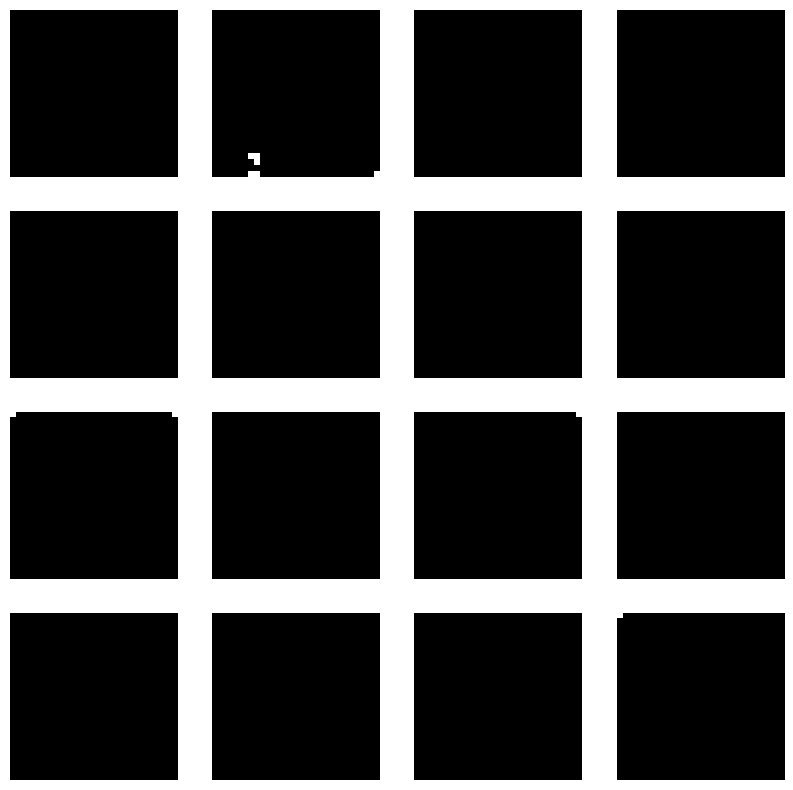

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1 average loss: 0.07564653203649035


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


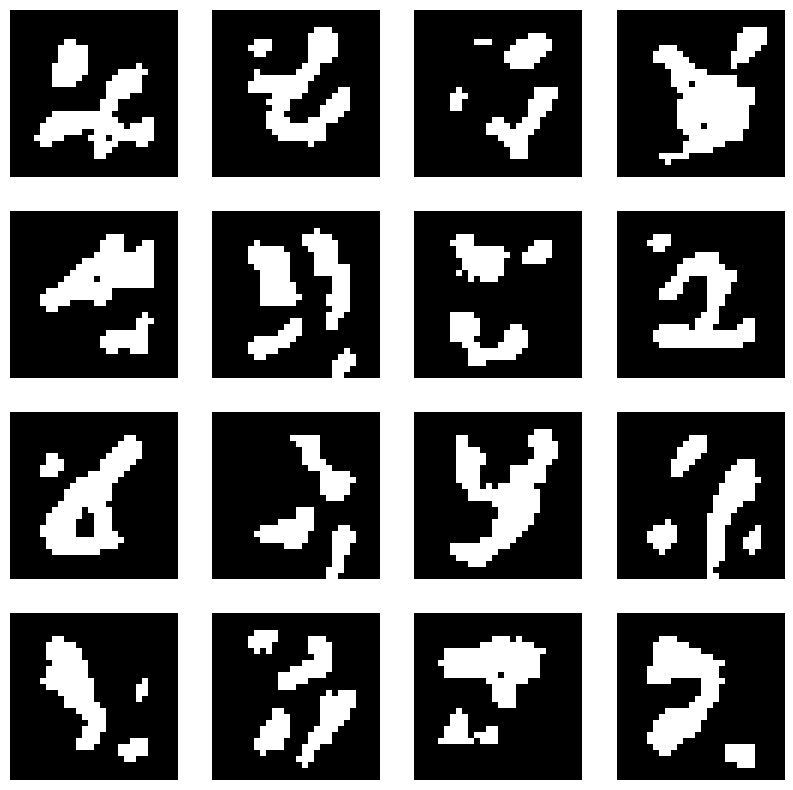

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2 average loss: 0.05966227826804428


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 3 average loss: 0.054585212052373565


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 4 average loss: 0.05173133443093906


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 5 average loss: 0.04970178402707738


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


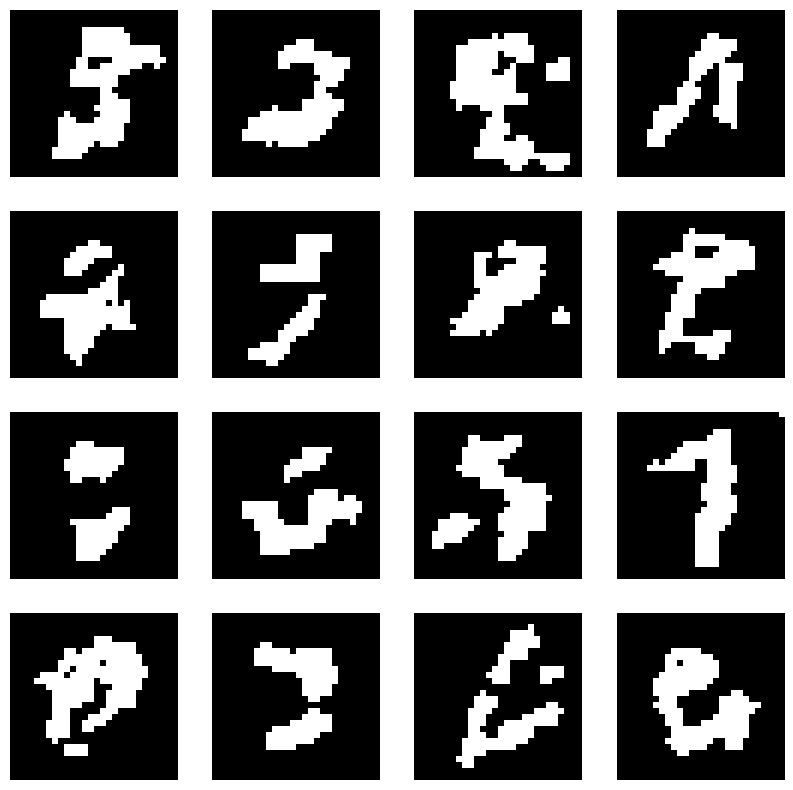

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 6 average loss: 0.04831691945003251


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 7 average loss: 0.0469407772613784


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 9 average loss: 0.044760488857657224


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 10 average loss: 0.0438316992594529


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


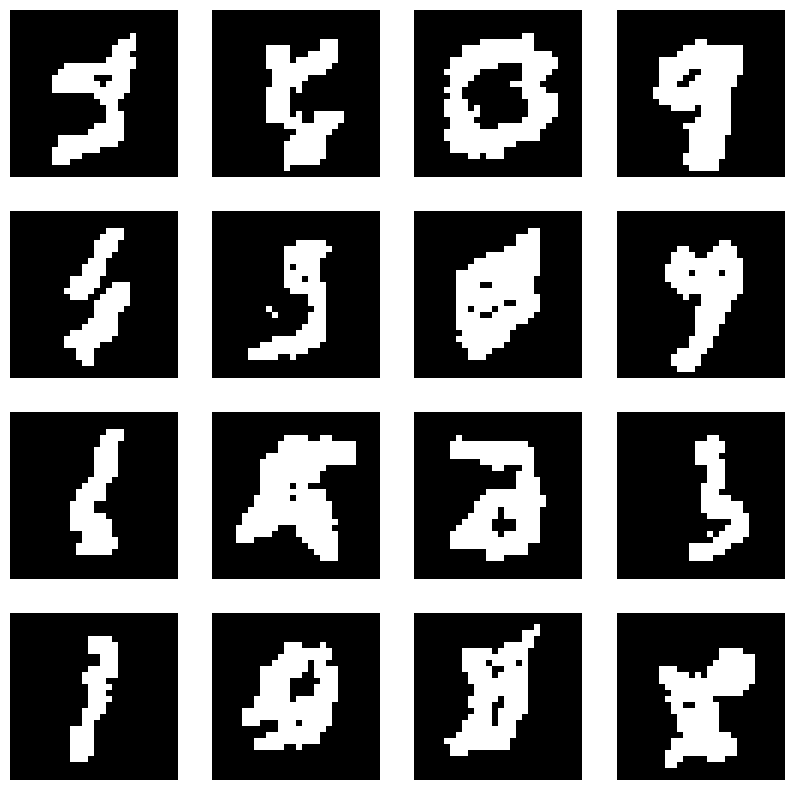

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 11 average loss: 0.0430436836776592


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 12 average loss: 0.042441536404066164


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 14 average loss: 0.04123793352963561


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 15 average loss: 0.040818255142135135


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


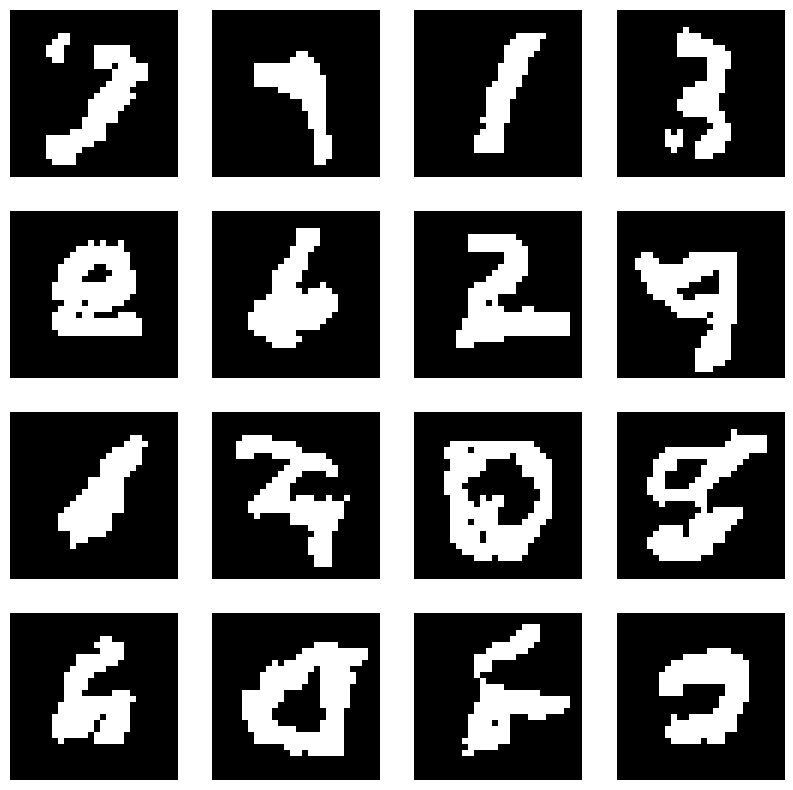

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 16 average loss: 0.04049545835893033


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 17 average loss: 0.04007069005678266


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 19 average loss: 0.03956201937744173


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 20 average loss: 0.03915588112579564


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


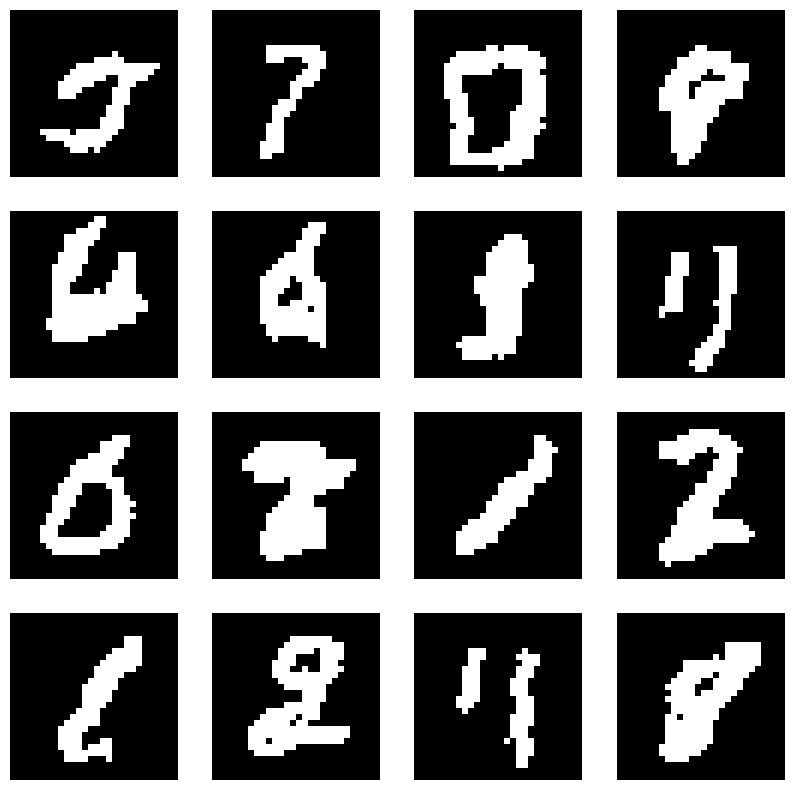

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 21 average loss: 0.039035045115624445


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 22 average loss: 0.03879037887741953


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 24 average loss: 0.03838494596845013


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 25 average loss: 0.03806991136427653


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


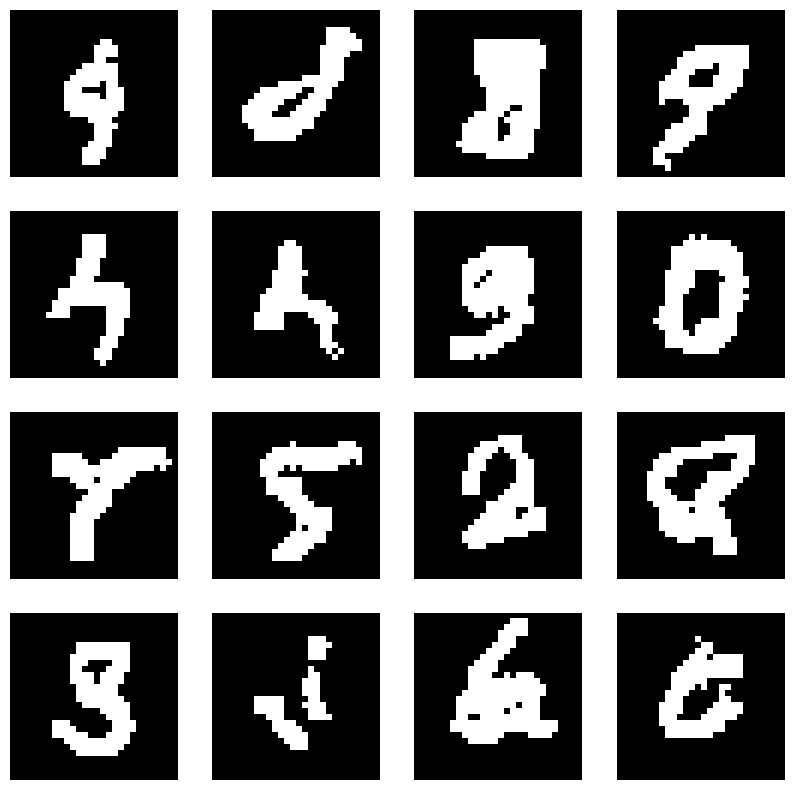

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 26 average loss: 0.03791570215154502


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 27 average loss: 0.03782972005211701


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 29 average loss: 0.03737293079621711


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30 average loss: 0.0372773042674792


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


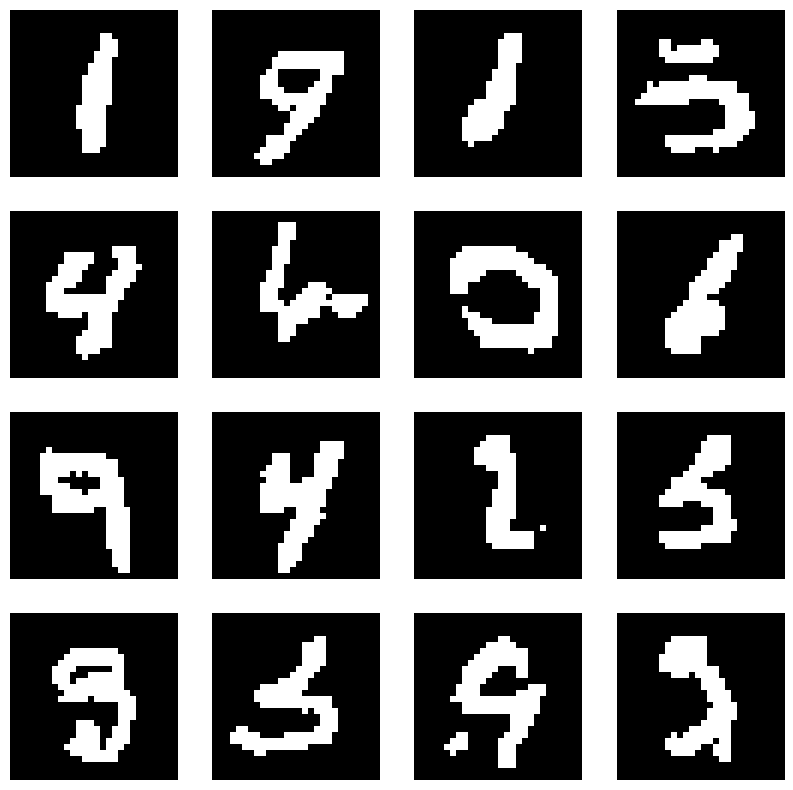

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 31 average loss: 0.03702672643555423


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 32 average loss: 0.036985585434457006


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 34 average loss: 0.036776939564842286


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 35 average loss: 0.03657151970191527


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


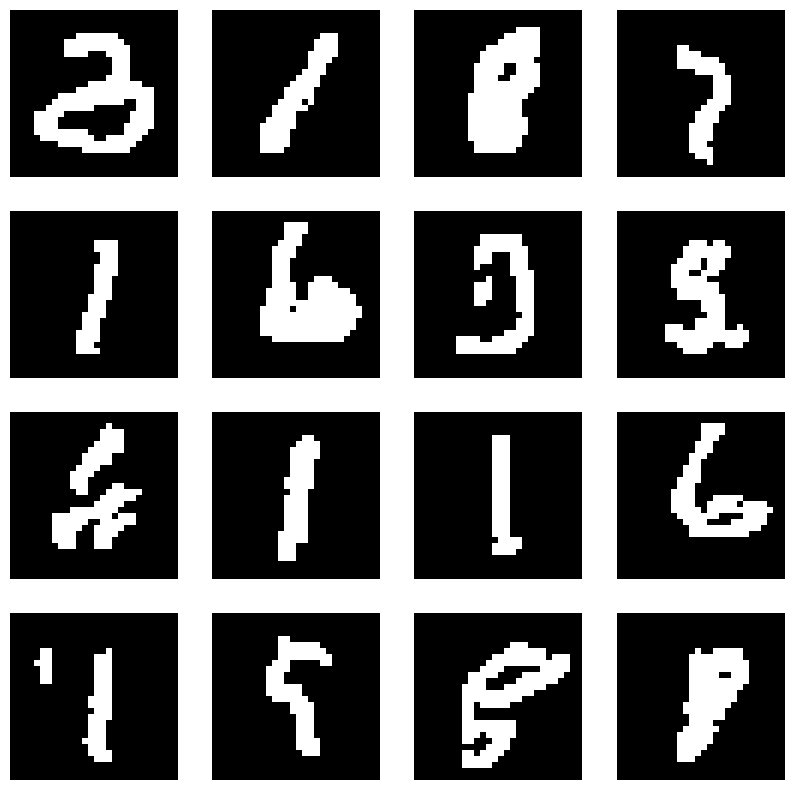

  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 36 average loss: 0.0364660088414863


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 37 average loss: 0.03639265882261729


  0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 39 average loss: 0.0360500261629537


  0%|          | 0/118 [00:00<?, ?it/s]

Epoch 40 average loss: 0.03598425275314662


  0%|          | 0/1000 [00:00<?, ?it/s]

(16, 28, 28)


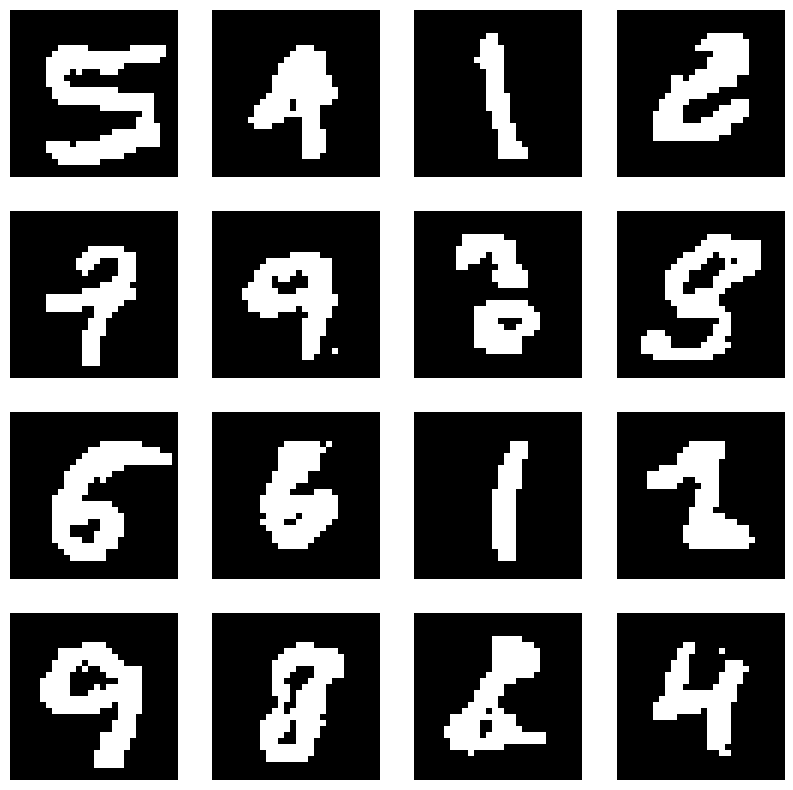

Model trained in 41 epochs.


In [14]:
from accelerate import notebook_launcher

def train_wrapper(config, unet, bfn, optim, train_loader, eval_img_batch):
    return train_model(config, bfn, optim, train_loader, eval_img_batch)  # Pass only bfn and optim to train_model

filename = 'bfn'
eval_img_batch = get_first_sample(test_loader)

modelpath = os.path.join(config.model_output_dir, filename)
if not os.path.exists(modelpath):
  os.makedirs(modelpath)

if os.listdir(modelpath):
  print("Loading pretrained model...")
  bfn = BayesianFlowNetwork2D(network=unet, D=28, K=2,) #initialise the model with original config

  # Load the state_dict into the initialized model
  bfn.load_state_dict(torch.load(os.path.join(modelpath, "bfn.pt"), map_location=config.device))
  bfn.to(config.device)  # Move model to the proper device
else:
  print("Training new model...")

  # Define a wrapper function that takes the unpacked arguments and calls train_model with the correct number of arguments

  args = (config, unet, bfn, optim, train_loader,  eval_img_batch)

  notebook_launcher(train_wrapper, args, num_processes=1)  # Use the wrapper function

  # Save the model
  if accelerator.is_main_process:
      unwrapped_model = accelerator.unwrap_model(bfn)
      torch.save(unwrapped_model.state_dict(), os.path.join(modelpath, "bfn.pt"))


##Alternative Training Method
If the previous block leads to error "No such file or directory: 'nvidia-smi'", please comment out and execute this block instead.


In [15]:
"""
train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
filename = 'diffusion'
# Initialisie accelerator

accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )

modelpath = os.path.join(config.model_output_dir, filename)
if not os.path.exists(modelpath):
    os.makedirs(modelpath)


if accelerator.is_main_process:

      pipeline.save_pretrained(modelpath)
      unwrapped_model = accelerator.unwrap_model(bfn)
      torch.save(unwrapped_model.state_dict(), os.path.join(modelpath, "bfn.pt"))
      """


'\ntrain_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)\nfilename = \'diffusion\'\n# Initialisie accelerator\n\naccelerator = Accelerator(\n        mixed_precision=config.mixed_precision,\n        gradient_accumulation_steps=config.gradient_accumulation_steps,\n    )\n\nmodelpath = os.path.join(config.model_output_dir, filename)\nif not os.path.exists(modelpath):\n    os.makedirs(modelpath)\n\n\nif accelerator.is_main_process:\n\n      pipeline.save_pretrained(modelpath)\n      unwrapped_model = accelerator.unwrap_model(bfn)\n      torch.save(unwrapped_model.state_dict(), os.path.join(modelpath, "bfn.pt"))\n      '

# Visualisation/Results

In this section we visualise the results from the previous training.  

  0%|          | 0/1000 [00:00<?, ?it/s]

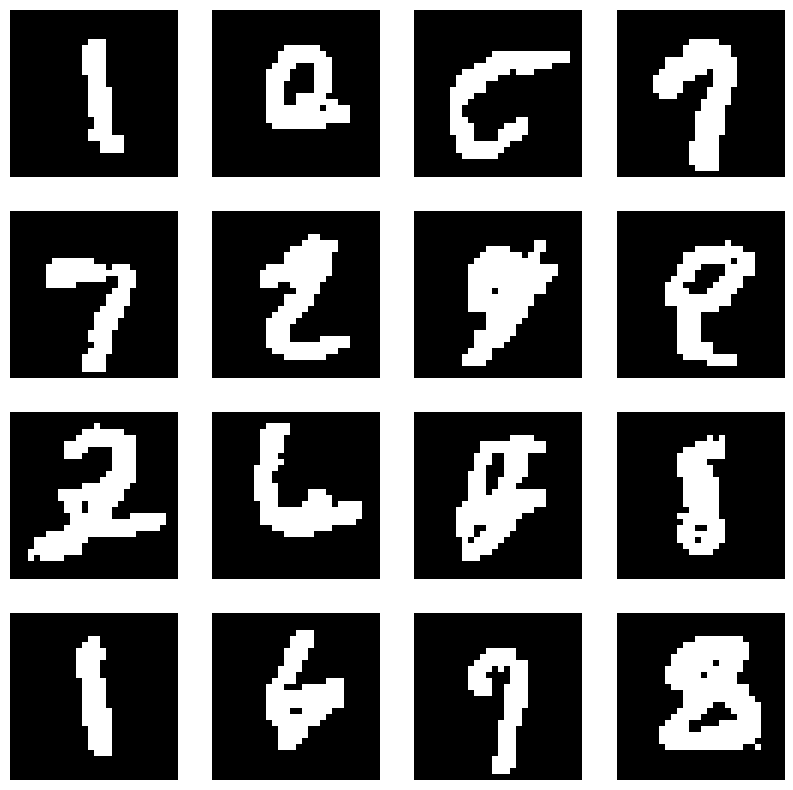

In [16]:
# Visualise the result
# Generate some images
images = bfn.sample(device=config.device.type, nb_steps=1000, batch_size=16, ema=ema)
path = config.results_output_dir + "/final_example_generation.png"
visualisation.show_results(images, path)

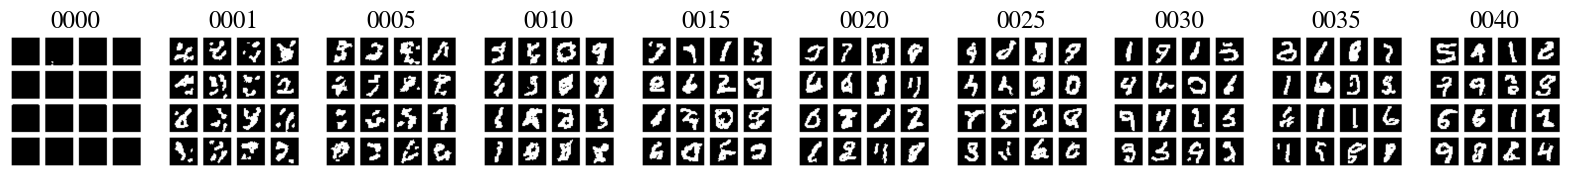

In [17]:
import glob
# Visualise the results of the training process per iteration
# load images from result repository
sample_images = sorted(glob.glob(f"{config.results_output_dir}/training_samples/*.png"))

path = config.results_output_dir + "/training_epoch_visualisation.png"
visualisation.plot_training_visualisation(sample_images, path)

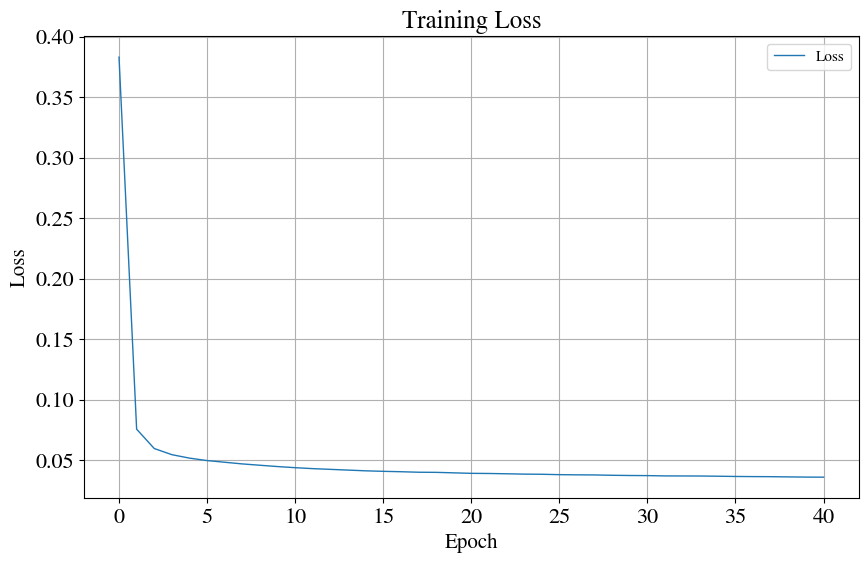

In [18]:
# Visualise the loss
loss_path = config.results_output_dir + "epoch_losses.json"
with open(loss_path, 'r') as f:
    losses = json.load(f)

path = config.results_output_dir + "/training_loss.png"
visualisation.plot_loss(losses, path)

Visualizing noising process for a single image without the original image.


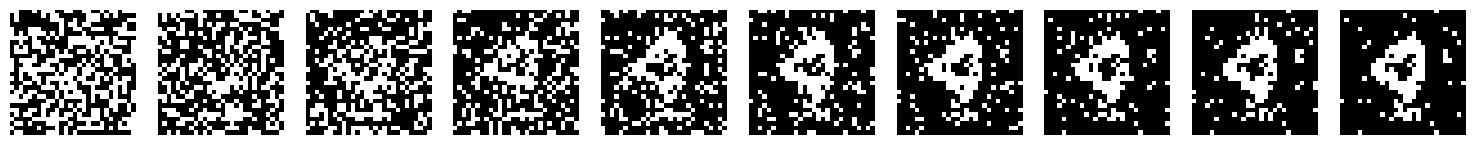

In [19]:
# Visualise denoising process
# Fetch the first batch using next()
data_iter = iter(train_loader)
first_batch = next(data_iter)
images = first_batch[0]
images = images.to(config.device)  # Move images to GPU
# Clamp the values in 'images' to be non-negative before passing to process
images = torch.clamp(images, min=0, max=1)
# Set model to evaluation mode
model = bfn.eval()
path = config.results_output_dir + "/denoising_process.png"
visualisation.visualize_noising_single_image_bfn(model, images[0], nb_steps=10, ema=ema)

# Optionally: Download Results
Function for Google Colab to download the model and results from local runtime.


In [20]:
!zip -r bfn_models.zip models
from google.colab import files
files.download('bfn_models.zip')

  adding: models/ (stored 0%)
  adding: models/bfn/ (stored 0%)
  adding: models/bfn/bfn.pt (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
!zip -r results_bfn.zip results
from google.colab import files
files.download('results_bfn.zip')

  adding: results/ (stored 0%)
  adding: results/bfn/ (stored 0%)
  adding: results/bfn/training_samples/ (stored 0%)
  adding: results/bfn/training_samples/0001.png (deflated 50%)
  adding: results/bfn/training_samples/0010.png (deflated 54%)
  adding: results/bfn/training_samples/.ipynb_checkpoints/ (stored 0%)
  adding: results/bfn/training_samples/0000.png (deflated 87%)
  adding: results/bfn/training_samples/0015.png (deflated 54%)
  adding: results/bfn/training_samples/0030.png (deflated 56%)
  adding: results/bfn/training_samples/0020.png (deflated 55%)
  adding: results/bfn/training_samples/0025.png (deflated 56%)
  adding: results/bfn/training_samples/0005.png (deflated 54%)
  adding: results/bfn/training_samples/0040.png (deflated 55%)
  adding: results/bfn/training_samples/0035.png (deflated 57%)
  adding: results/bfn/epoch_losses.json (deflated 56%)
  adding: results/bfn/training_loss.png (deflated 19%)
  adding: results/bfn/final_example_generation.png (deflated 57%)
  add

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>